In [173]:
# Package imports

import torch
import vizdoom
import vizdoom
from vizdoom import gymnasium_wrapper
import gymnasium
import yaml

In [174]:
# Sys level imports

import sys
sys.path.append('.')
from scripts.env_setup import collect_rollouts, batch_frames
from models.vae import VAE
from models.mdnrnn import MDNRNN

Environment and config

In [175]:
with open("config.yaml", "r") as f:
    CONFIG = yaml.safe_load(f)

# Vizdoom env variables
VIZDOOM_CONFIG = CONFIG["vizdoom-env"]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

VAE_TRAINING_PARAMS = CONFIG["vae"]["training-params"]
VAE_MODEL_LOC = CONFIG["vae"]["model-path"]

MDNRNN_TRAINING_PARAMS = CONFIG["mdnrnn"]["training-params"]
MDNRNN_MODEL_LOC = CONFIG["mdnrnn"]["model-path"]

In [176]:
env = gymnasium.make(VIZDOOM_CONFIG, screen_resolution=vizdoom.ScreenResolution.RES_200X125)
frames, actions, game_states, rewards, done_list = collect_rollouts(env=env, episodes=1)

Rolling out Episode: 1/1: 100%|██████████| 1/1 [00:00<00:00,  1.71it/s]


In [177]:
import matplotlib.pyplot as plt

game = game_states[0][0]
action = actions[0][0]
print("Game state:", game)
print("Action variable:", action)

Game state: [ 79. 100.]
Action variable: tensor([0, 1, 0, 0])


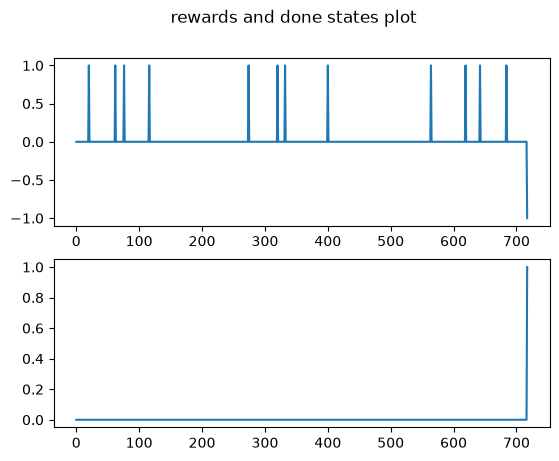

In [178]:
fig, ax = plt.subplots(2)
fig.suptitle('rewards and done states plot')
ax[0].plot(rewards[0])
ax[1].plot(done_list[0])

VAE -> Testing the VAE

In [179]:
vae = VAE(CONFIG["latent-dim"]).to(DEVICE)
vae_dict = torch.load(VAE_MODEL_LOC)
vae.load_state_dict(vae_dict)
vae.eval()

batch_frames = batch_frames(frames, batch_size=1)
frame = next(iter(batch_frames))
x_hat, z, _, _  = vae(frame.to(DEVICE))

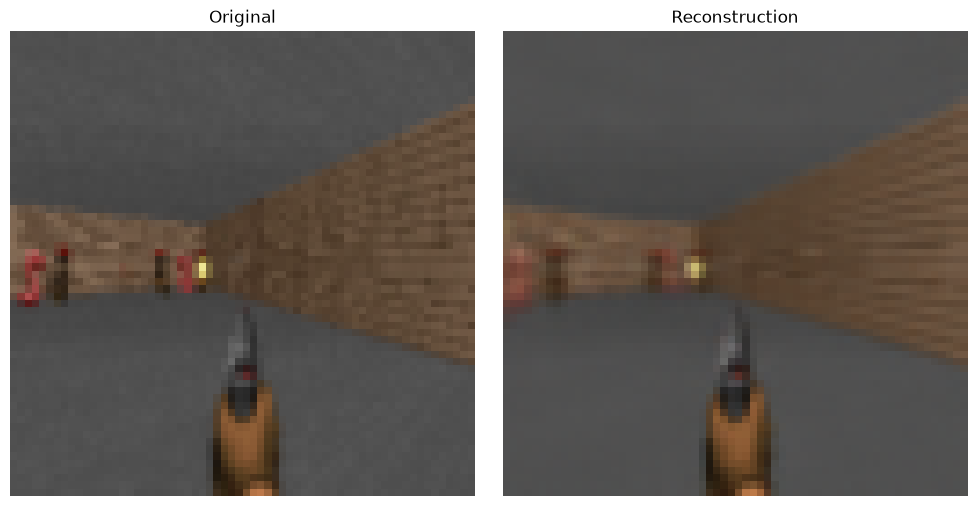

In [180]:
recon = torch.sigmoid(x_hat[0]).detach().cpu().permute(1, 2, 0)
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(frame[0].permute(1, 2, 0))
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(recon)
ax[1].set_title("Reconstruction")
ax[1].axis("off")

plt.tight_layout()
plt.show()

MDNRNN evaluation 

In [181]:
frame = frames[0][0].unsqueeze(0).to(DEVICE)
print(frame.shape)
x_hat, z, _, _ = vae(frame)

torch.Size([1, 3, 64, 64])


In [182]:
from models.mdnrnn import MDNRNN

mdnrnn = MDNRNN(
        latent_dim=CONFIG["latent-dim"],
        hidden_dim=MDNRNN_TRAINING_PARAMS["hidden-dim"],
        action_dim=CONFIG["action-dim"],
        game_state_dim=CONFIG["game-state-dim"],
        mixtures=MDNRNN_TRAINING_PARAMS["mixtures"]
        ).to(DEVICE)

mdnrnn_dict = torch.load(MDNRNN_MODEL_LOC)
mdnrnn.load_state_dict(state_dict=mdnrnn_dict)
mdnrnn.eval()

MDNRNN(
  (rnn): LSTM(134, 32)
  (mdn): Linear(in_features=32, out_features=1285, bias=True)
  (reward_head): Linear(in_features=32, out_features=1, bias=True)
  (done_head): Linear(in_features=32, out_features=1, bias=True)
)

In [183]:
action = torch.as_tensor(actions[0][0]).unsqueeze(0).to(DEVICE)
game_state = torch.as_tensor(game_states[0][0]).unsqueeze(0).to(DEVICE)

h = torch.zeros(1, 1, mdnrnn.hidden_dim, device=DEVICE)
c = torch.zeros(1, 1, mdnrnn.hidden_dim, device=DEVICE)

z = z.unsqueeze(0)
action = action.unsqueeze(0)
game_state = game_state.unsqueeze(0)

print(z.shape)
print(action.shape)
print(game_state.shape)

gmm, h, c, r, d = mdnrnn(
    z=z, a=action, g=game_state, h=h, c=c
)

torch.Size([1, 1, 128])
torch.Size([1, 1, 4])
torch.Size([1, 1, 2])


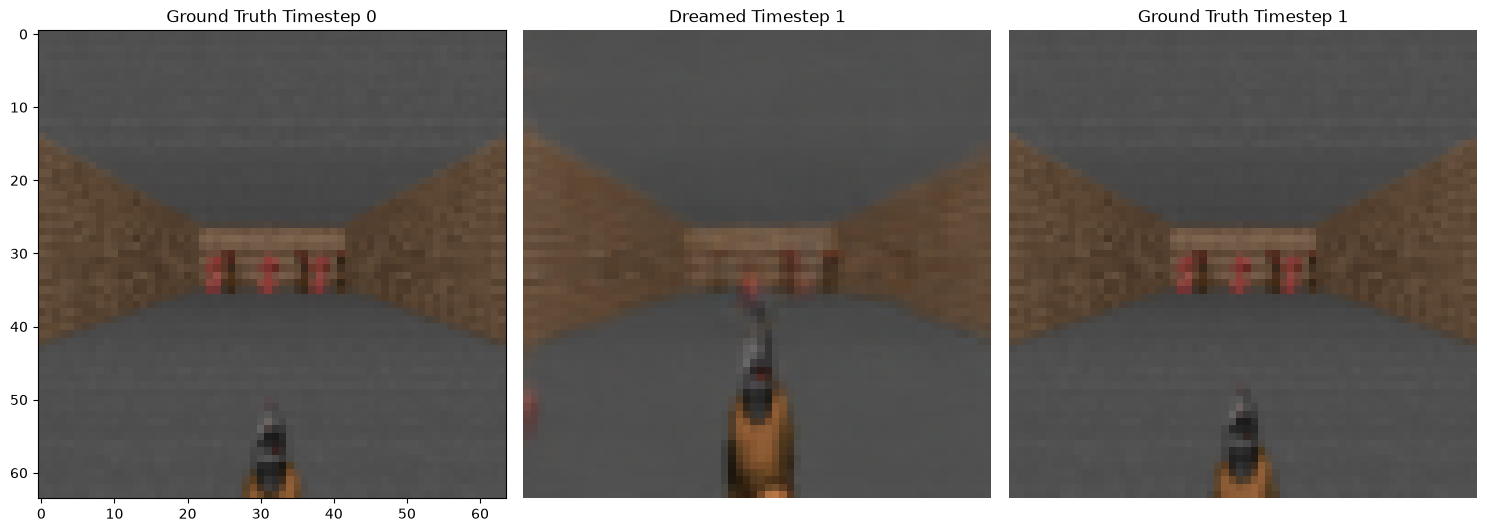

In [184]:
z_next = gmm.sample()
z_next = vae.restructure(z_next)
z_next = z_next.view(-1, 128, 8, 8)
out = vae.decoder(z_next)
out = torch.sigmoid(out[0]).cpu().detach().permute(1,2,0)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(frames[0][0].permute(1, 2, 0))
ax[0].set_title("Ground Truth Timestep 0")
ax[1].axis("off")

ax[1].imshow(out)
ax[1].set_title("Dreamed Timestep 1")
ax[1].axis("off")

ax[2].imshow(frames[0][1].permute(1, 2, 0))
ax[2].set_title("Ground Truth Timestep 1")
ax[2].axis("off")

plt.tight_layout()
plt.show()

MDNRNN Episode per frame basis

In [185]:
frames_episode = torch.stack([frame for frame in frames[0]]).to(DEVICE)
print(frames_episode.shape)
x_hat_ep, z_ep, _, _ = vae(frames_episode)
z_ep = z_ep.unsqueeze(0)

torch.Size([718, 3, 64, 64])


In [186]:
actions_episode = torch.as_tensor(actions[0]).unsqueeze(0).to(DEVICE)
game_states_episode = torch.as_tensor(game_states[0]).unsqueeze(0).to(DEVICE)
print(actions_episode.shape)
print(game_states_episode.shape)

torch.Size([1, 718, 4])
torch.Size([1, 718, 2])


In [187]:
h = torch.zeros(1, z_ep.shape[1], mdnrnn.hidden_dim, device=DEVICE)
c = torch.zeros(1, z_ep.shape[1], mdnrnn.hidden_dim, device=DEVICE)

print(z.shape)
print(action.shape)
print(game_state.shape)

gmm, h, c, r, d = mdnrnn(
    z=z_ep, a=actions_episode, g=game_states_episode, h=h, c=c
)

torch.Size([1, 1, 128])
torch.Size([1, 1, 4])
torch.Size([1, 1, 2])


In [188]:
time_series = 5

z_next = gmm.sample()
z_next_ep = vae.restructure(z_next)
z_next_ep = z_next_ep.reshape(-1, 128, 8, 8)

out_ep = torch.sigmoid(vae.decoder(z_next_ep))

out_ep = torch.sigmoid(vae.decoder(z_next_ep))
print(out_ep.shape)

torch.Size([718, 3, 64, 64])


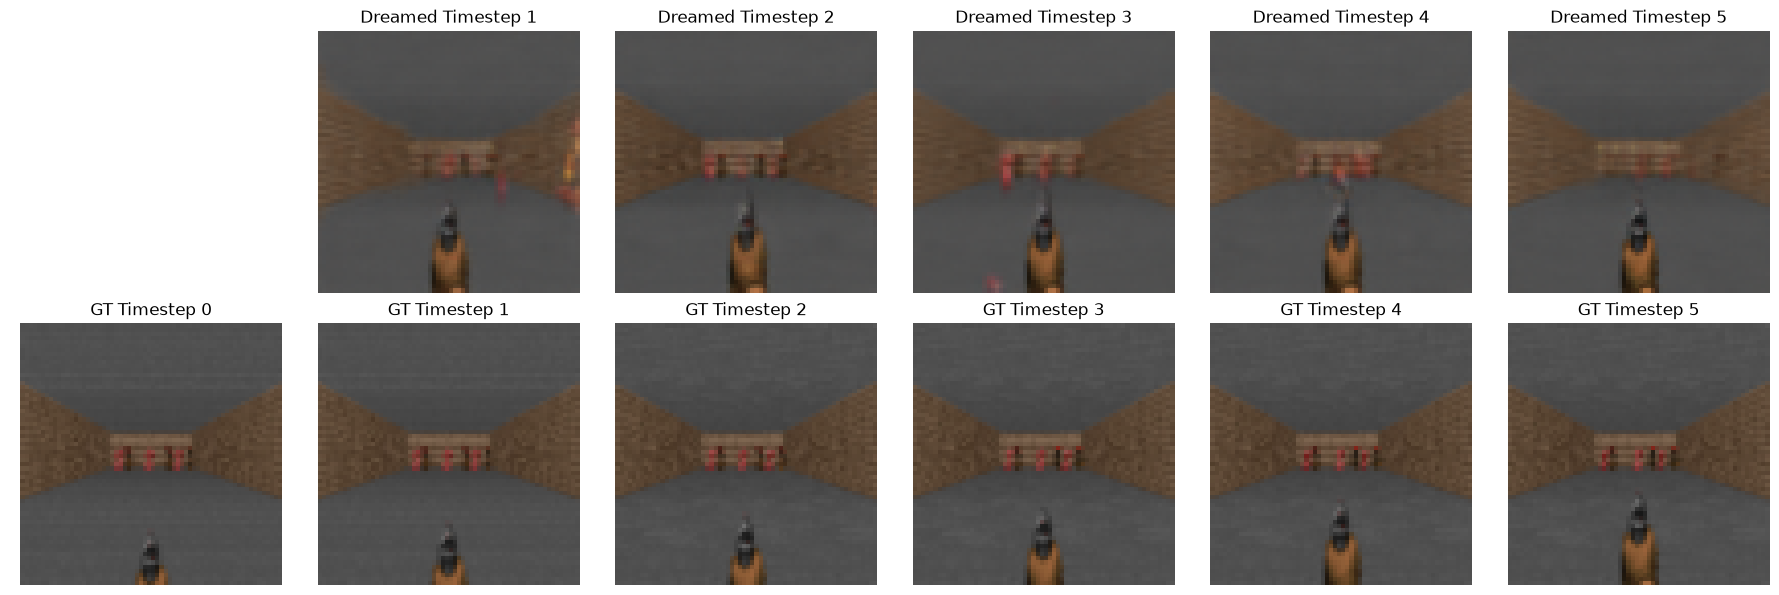

In [189]:
fig, ax = plt.subplots(2, time_series + 1, figsize=(18, 6))

ax[0][0].axis('off')

for t in range(time_series):
    frame = out_ep[t].detach().cpu().permute(1, 2, 0)
    ax[0][t + 1].imshow(frame)
    ax[0][t + 1].set_title(f"Dreamed Timestep {t + 1}")
    ax[0][t + 1].axis("off")

for t in range(time_series + 1):
    frame = frames_episode[t].detach().cpu().permute(1, 2, 0)
    ax[1][t].imshow(frame)
    ax[1][t].set_title(f"GT Timestep {t}")
    ax[1][t].axis("off")

plt.tight_layout()
plt.show()

In [190]:
from sklearn.decomposition import PCA
import numpy as np

In [191]:
z_ep = z_ep.squeeze(0)
print(z_ep.shape)
print(z_next.shape)
z_diff = z_next[:-1] - z_ep[1:]
z_diff = z_diff.detach().cpu()

torch.Size([718, 128])
torch.Size([718, 128])


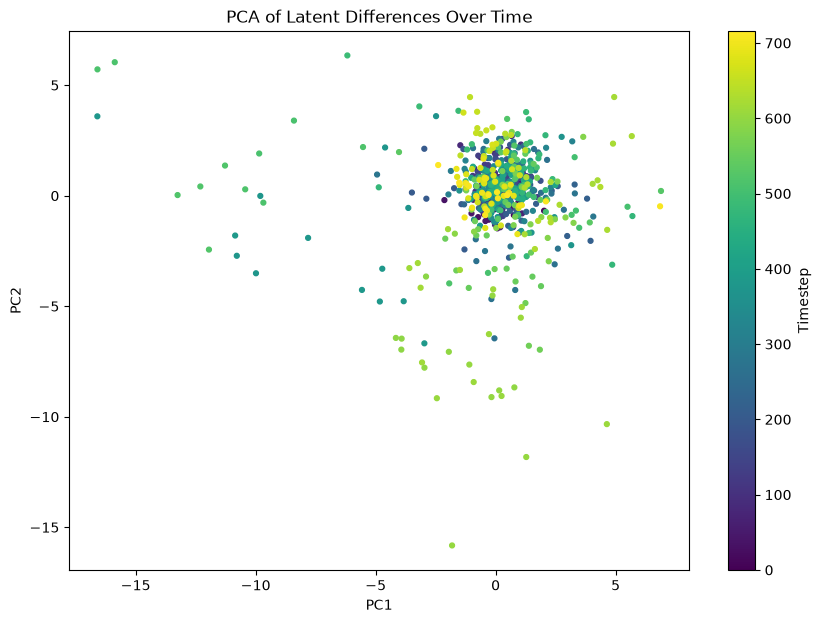

In [192]:
pca = PCA(n_components=2)
z_significant = pca.fit_transform(z_diff)

fig, ax = plt.subplots(figsize=(10, 7))

sc = ax.scatter(
    z_significant[:, 0],
    z_significant[:, 1],
    c=np.arange(len(z_significant)),
    cmap="viridis",
    s=12
)

plt.colorbar(sc, ax=ax, label="Timestep")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA of Latent Differences Over Time")
plt.show()

MDNRNN Rollout

In [193]:
action = torch.as_tensor(
    actions[0][0], dtype=torch.float32, device=DEVICE
).reshape(1, 1, -1)

game_state = torch.as_tensor(
    game_states[0][0], dtype=torch.float32, device=DEVICE
).reshape(1, 1, -1)

# Initial latent state: one timestep, one batch, 128 features
z = z.reshape(1, 1, -1)

h = torch.zeros(1, 1, mdnrnn.hidden_dim, device=DEVICE)
c = torch.zeros(1, 1, mdnrnn.hidden_dim, device=DEVICE)

z_rollout = [z.detach().clone()]
max_steps = len(actions[0])
d_rollout = []

with torch.no_grad():
    for t in range(max_steps):
        gmm, h, c, r, d = mdnrnn(
            z=z, a=action, g=game_state, h=h, c=c
        )

        done_prob = torch.sigmoid(d).item()
        print(f"Step {t + 1}: done probability = {done_prob:.4f}")

        # Sample the next latent state
        z = gmm.sample()  # expected shape (1, 1, 128)
        z = z.unsqueeze(0)
        z_rollout.append(z.detach().clone())
        d_rollout.append(done_prob)

        if done_prob > 0.9:
            print("Predicted episode termination.")
            break

print("Rollout length:", len(z_rollout) - 1)

Step 1: done probability = 0.0000
Step 2: done probability = 0.0000
Step 3: done probability = 0.0000
Step 4: done probability = 0.0000
Step 5: done probability = 0.0000
Step 6: done probability = 0.0000
Step 7: done probability = 0.0000
Step 8: done probability = 0.0000
Step 9: done probability = 0.0000
Step 10: done probability = 0.0000
Step 11: done probability = 0.0000
Step 12: done probability = 0.0000
Step 13: done probability = 0.0000
Step 14: done probability = 0.0000
Step 15: done probability = 0.0000
Step 16: done probability = 0.0000
Step 17: done probability = 0.0000
Step 18: done probability = 0.0000
Step 19: done probability = 0.0000
Step 20: done probability = 0.0000
Step 21: done probability = 0.0000
Step 22: done probability = 0.0000
Step 23: done probability = 0.0000
Step 24: done probability = 0.0000
Step 25: done probability = 0.0000
Step 26: done probability = 0.0000
Step 27: done probability = 0.0000
Step 28: done probability = 0.0000
Step 29: done probability = 0

Text(0.5, 1.0, 'Pred done')

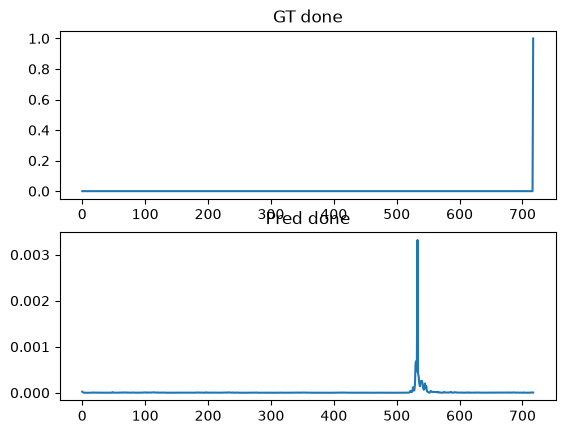

In [194]:
fig, ax = plt.subplots(2)

ax[0].plot(done_list[0])
ax[0].set_title("GT done")

ax[1].plot(d_rollout)
ax[1].set_title("Pred done")

In [195]:
done = done_list[0]

n_pos = sum(done)
n_neg = len(done) - n_pos

print("Total:", len(done))
print("Done = True:", n_pos)
print("Done = False:", n_neg)
print("Positive fraction:", n_pos / len(done))
print("Negative / positive ratio:", n_neg / n_pos)

Total: 718
Done = True: 1
Done = False: 717
Positive fraction: 0.001392757660167131
Negative / positive ratio: 717.0


In [196]:
print("Max prediction probability is:", max(d_rollout))

Max prediction probability is: 0.0033188010565936565
